In [1]:
import pandas as pd
import torch
from pathlib import Path
from torch_geometric.data import Data
import numpy as np
from torch_geometric.utils import degree
import matplotlib.pyplot as plt

#  Configuration
pd.set_option('display.max_columns', 5)

In [2]:
#  File Paths 
DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw") 

# Ensure the processed directory exists
DATA_PROCESSED.mkdir(exist_ok=True)

## 1. Elliptic Dataset Assembly (CSV to Graph)

In [3]:
# File paths
features_path = DATA_RAW / "elliptic_txs_features.csv"
classes_path = DATA_RAW / "elliptic_txs_classes.csv"
edgelist_path = DATA_RAW / "elliptic_txs_edgelist.csv"

# Load into pandas DataFrames
df_features = pd.read_csv(features_path, header=None)
df_classes = pd.read_csv(classes_path)
df_edgelist = pd.read_csv(edgelist_path)

print("Files loaded successfully.")
print(f"Features shape: {df_features.shape}")
print(f"Classes shape:  {df_classes.shape}")
print(f"Edge list shape: {df_edgelist.shape}")

Files loaded successfully.
Features shape: (203769, 167)
Classes shape:  (203769, 2)
Edge list shape: (234355, 2)


In [4]:
# The first column of the features file contains the unique transaction IDs
tx_ids = df_features.iloc[:, 0].values

# Create the mapping from the raw ID to our new integer index
id_map = {tx_id: i for i, tx_id in enumerate(tx_ids)}
num_nodes = len(id_map)

print(f"Created a mapping for {num_nodes:,} unique transaction nodes.")
print("Example mapping:")
print(f"  - Transaction ID {tx_ids[0]} - Node Index 0")
print(f"  - Transaction ID {tx_ids[1]} - Node Index 1")

Created a mapping for 203,769 unique transaction nodes.
Example mapping:
  - Transaction ID 230425980 - Node Index 0
  - Transaction ID 5530458 - Node Index 1


In [5]:
# Map the source and destination transaction IDs to our new integer indices
src_mapped = df_edgelist['txId1'].map(id_map).values
dst_mapped = df_edgelist['txId2'].map(id_map).values

# Create the final edge_index tensor
edge_index = torch.tensor([src_mapped, dst_mapped], dtype=torch.long)

print("Edge index constructed successfully.")
print(f"Shape of edge_index: {edge_index.shape}")

Edge index constructed successfully.
Shape of edge_index: torch.Size([2, 234355])


In [6]:
#  Feature Tensor
feature_values = df_features.iloc[:, 2:].values
x = torch.tensor(feature_values, dtype=torch.float)

print(f"Feature tensor 'x' created with shape: {x.shape}")

#  Label Tensor
df_features.rename(columns={0: 'txId'}, inplace=True)
df_merged = df_features[['txId']].merge(df_classes, on='txId', how='left')

# Define the mapping for the classes
class_map_dict = {'unknown': -1, '2': 0, '1': 1} # '2' is Licit, '1' is Illicit
y_values = df_merged['class'].map(class_map_dict).values
y = torch.tensor(y_values, dtype=torch.long)

print(f"Label tensor 'y' created with shape: {y.shape}")
print("\nLabel distribution:")
print(f"  - Licit (0):   {(y == 0).sum():,}")
print(f"  - Illicit (1):   {(y == 1).sum():,}")
print(f"  - Unknown (-1): {(y == -1).sum():,}")

Feature tensor 'x' created with shape: torch.Size([203769, 165])
Label tensor 'y' created with shape: torch.Size([203769])

Label distribution:
  - Licit (0):   42,019
  - Illicit (1):   4,545
  - Unknown (-1): 157,205


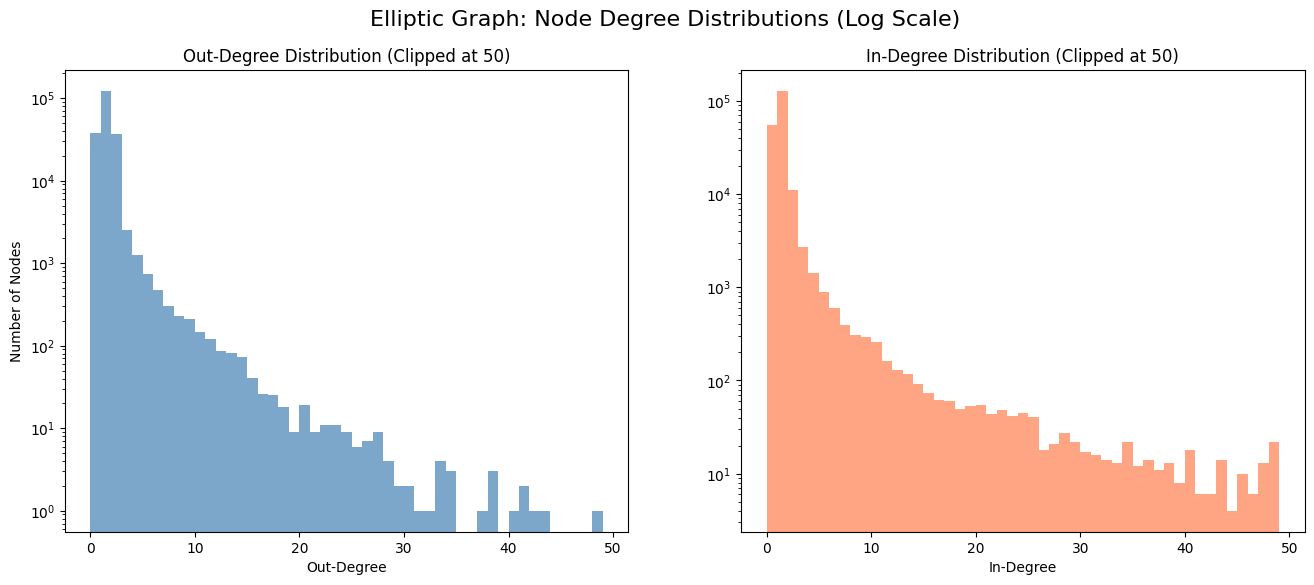

In [7]:
#  Visualize Degree Distribution 
out_degrees = degree(edge_index[0], num_nodes=num_nodes)
in_degrees = degree(edge_index[1], num_nodes=num_nodes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(out_degrees.numpy(), bins=range(0, 50), alpha=0.7, color='steelblue')
axes[0].set_title('Out-Degree Distribution (Clipped at 50)')
axes[0].set_xlabel('Out-Degree')
axes[0].set_ylabel('Number of Nodes')
axes[0].set_yscale('log')

axes[1].hist(in_degrees.numpy(), bins=range(0, 50), alpha=0.7, color='coral')
axes[1].set_title('In-Degree Distribution (Clipped at 50)')
axes[1].set_xlabel('In-Degree')
axes[1].set_yscale('log')
plt.suptitle('Elliptic Graph: Node Degree Distributions (Log Scale)', fontsize=16)
plt.show()


In [7]:
# Add the timestep as an additional attribute for potential temporal analysis/splitting later
timesteps = torch.tensor(df_features.iloc[:, 1].values, dtype=torch.long)

elliptic_data = Data(x=x, edge_index=edge_index, y=y, timesteps=timesteps)

# Add the number of nodes explicitly for clarity
elliptic_data.num_nodes = num_nodes

# Save the final object
save_path = DATA_PROCESSED / "elliptic_graph.pt"
torch.save(elliptic_data, save_path)

print(f"\nFinal PyG Data object for Elliptic created:")
print(elliptic_data)
print(f"\nSaved successfully to: {save_path}")


Final PyG Data object for Elliptic created:
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], timesteps=[203769], num_nodes=203769)

Saved successfully to: ..\data\processed\elliptic_graph.pt


## 2. Synthetic Dataset Integration and Validation

In [8]:
# Path to the cleaned synthetic data file
synthetic_path = DATA_PROCESSED / "synthetic_fraud_clean.pt" # Update if you named it differently

if synthetic_path.exists():
    synthetic_data = torch.load(synthetic_path, weights_only=False)
    print("Synthetic dataset loaded successfully.")

    #  Validation Checks 
    print("\n Synthetic Data Validation ")
    print(f"Graph object type: {type(synthetic_data)}")
    
    # Check for required attributes
    has_x = hasattr(synthetic_data, 'x')
    has_edge_index = hasattr(synthetic_data, 'edge_index')
    has_y = hasattr(synthetic_data, 'y')
    
    print(f"Contains 'x' attribute:         {has_x}")
    print(f"Contains 'edge_index' attribute: {has_edge_index}")
    print(f"Contains 'y' attribute:         {has_y}")
    
    if all([has_x, has_edge_index, has_y]):
        print("\n Shape Consistency")
        print(f"Number of nodes:      {synthetic_data.num_nodes:,}")
        print(f"x shape:              {synthetic_data.x.shape}")
        print(f"y shape:              {synthetic_data.y.shape}")
        print(f"edge_index shape:     {synthetic_data.edge_index.shape}")
        
        # Critical check: Do the number of nodes in x and y match num_nodes?
        is_consistent = (synthetic_data.x.shape[0] == synthetic_data.num_nodes) and \
                        (synthetic_data.y.shape[0] == synthetic_data.num_nodes)
        
        print(f"\nShape consistency check passed: {is_consistent}")
        if not is_consistent:
            print("WARNING: Mismatch in number of nodes, features, or labels!")

else:
    print(f"ERROR: Synthetic data file not found at {synthetic_path}")
    print("Please ensure the synthetic data processing from Week 1/2 is complete.")

Synthetic dataset loaded successfully.

 Synthetic Data Validation 
Graph object type: <class 'torch_geometric.data.data.Data'>
Contains 'x' attribute:         True
Contains 'edge_index' attribute: True
Contains 'y' attribute:         True

 Shape Consistency
Number of nodes:      5,000
x shape:              torch.Size([5000, 12])
y shape:              torch.Size([5000])
edge_index shape:     torch.Size([2, 40900])

Shape consistency check passed: True


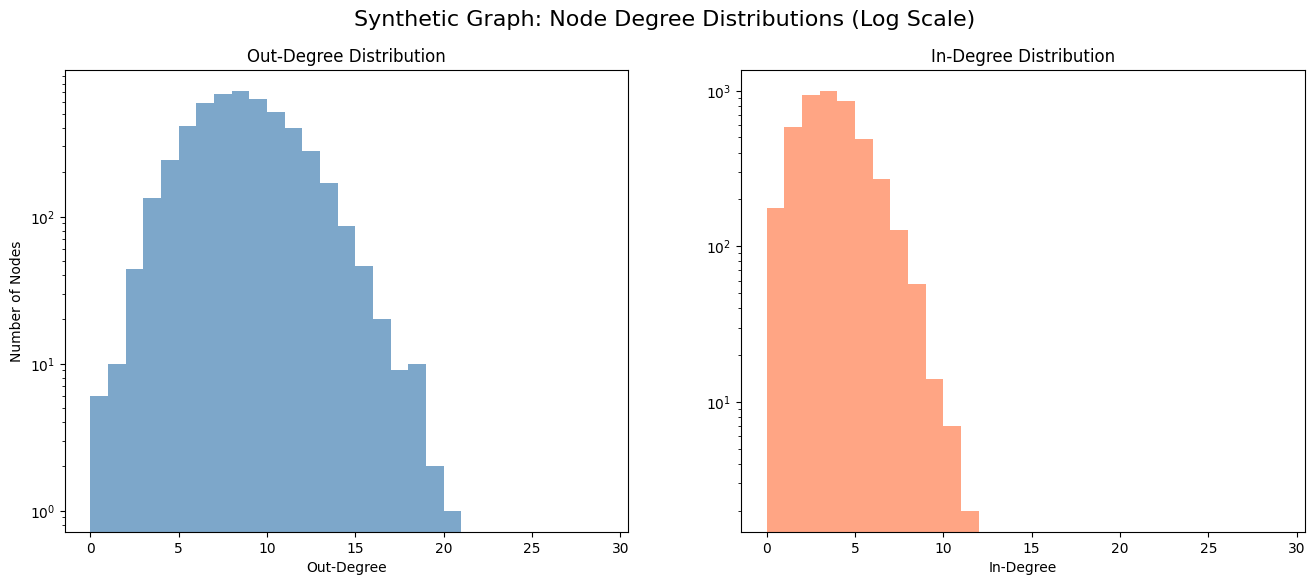

In [9]:
if synthetic_path.exists():

    # Visualize Degree Distribution
    synth_edge_index = synthetic_data.edge_index
    synth_num_nodes = synthetic_data.num_nodes
    
    synth_out_degrees = degree(synth_edge_index[0], num_nodes=synth_num_nodes)
    synth_in_degrees = degree(synth_edge_index[1], num_nodes=synth_num_nodes)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].hist(synth_out_degrees.numpy(), bins=range(0, 30), alpha=0.7, color='steelblue')
    axes[0].set_title('Out-Degree Distribution')
    axes[0].set_xlabel('Out-Degree')
    axes[0].set_ylabel('Number of Nodes')
    axes[0].set_yscale('log')

    axes[1].hist(synth_in_degrees.numpy(), bins=range(0, 30), alpha=0.7, color='coral')
    axes[1].set_title('In-Degree Distribution')
    axes[1].set_xlabel('In-Degree')
    axes[1].set_yscale('log')
    plt.suptitle('Synthetic Graph: Node Degree Distributions (Log Scale)', fontsize=16)
    plt.show()